In [1]:
import earthkit.plots as ekp
import earthkit.data as ekd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [2]:
YEARS = [str(y) for y in range(2013, 2026)]

In [3]:
%%capture
data = ekd.from_source(
    "cds",
    "reanalysis-era5-single-levels-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": "sea_ice_cover",
        "year": YEARS,
        "month": "09",
        "time": "00:00",
        "grid": [0.25, 0.25],
    },
).to_fieldlist()

In [4]:
data.ls(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,ci,2013-09-01,2013-09-01,0 days,0,surface,0,regular_ll
1,ci,2014-09-01,2014-09-01,0 days,0,surface,0,regular_ll


In [5]:
caption = "Data: ERA5 monthly averaged data on single levels from 1940 to present | DOI: 10.24381/cds.f17050d7  | Source: CDS | Created by: Bernadett Piros"

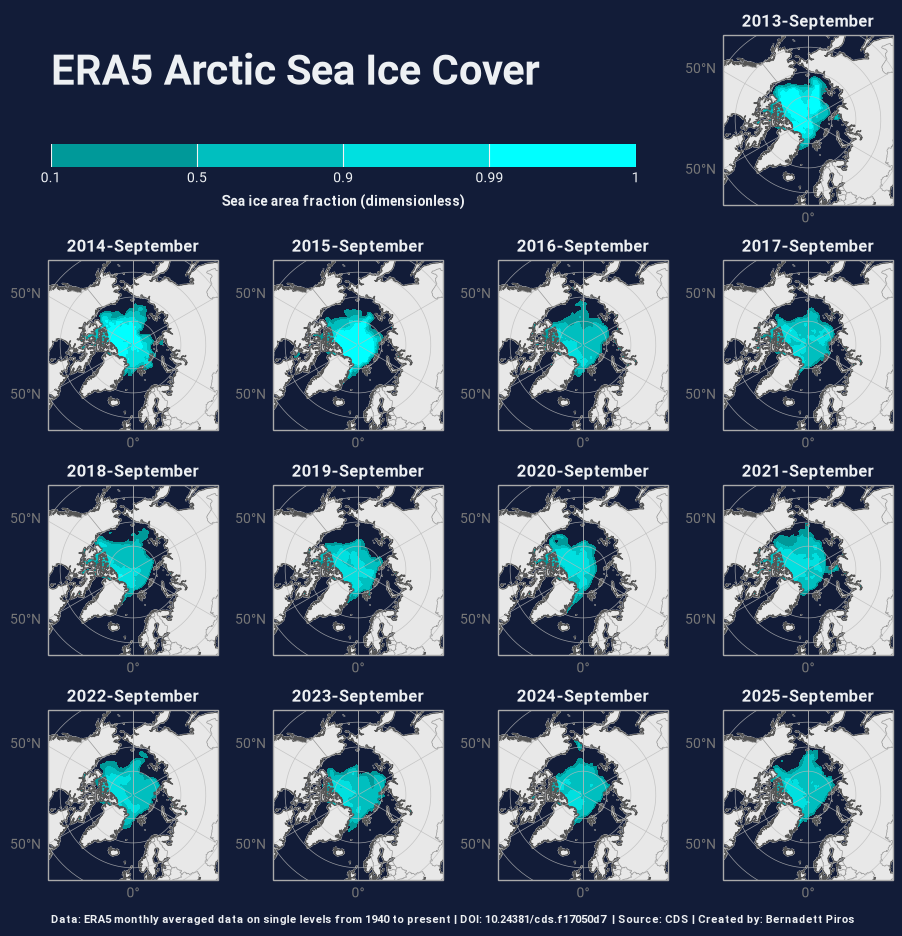

In [6]:
# Style to use 
style="sic-10to100"

# Dark figure background
plt.rcParams.update({
    "figure.facecolor": "#121C38", 
    "axes.facecolor": "#121C38",       
})

# Create figure 
figure = ekp.Figure(
    domain="Arctic",
    figsize=(9, 9),    
    rows=4,
    columns=4,
)

# Start at the top-right corner
figure.add_map(0, 3)
for i in range(12):
    figure.add_map(1 + i // 4, i % 4)

# Sea ice cover
figure.contourf(data.sel({"parameter.variable": "ci"}), style=style)

# Add standard layers
figure.standard_layers()

# Inset ax for the colorbar
ax = figure.fig.add_axes((0.05, 0.82, 0.65, 0.025))
cbar = figure.legend(ax=ax)[0]

# Colorbar aesthetics
cbar.outline.set_visible(False)
cbar.solids.set_edgecolor("face")
cbar.solids.set_linewidth(0)

# Colorbar labels
cbar.ax.xaxis.label.set_color("#EDF0F3")
cbar.ax.xaxis.label.set_weight("bold")
cbar.ax.tick_params(axis="x", colors="#EDF0F3")

# Add titles and subtitles
figure.subplot_titles("{time.valid_datetime:%Y-%B}", color="#EDF0F3", fontsize=12, weight="bold")
figure.title(
    "ERA5 Arctic Sea Ice Cover",
    fontsize=30,
    fontweight="bold",
    color="#EDF0F3",
    horizontalalignment="left",
    x=0.05,
    y=0.96,
)

# Add caption
figure.fig.text(0.05, -0.02, s=caption, color="#EDF0F3", fontsize=8, fontweight="bold")

figure.show()
#figure.save("arctic_sea_ice_dark_bg.png", dpi=300)